In [1]:
library(here)
library(pheatmap)
library(corrplot)

here() starts at D:/Studies/FINM_34700_MSA/FINM_34700_MSA

corrplot 0.95 loaded



### Problem 1

In [2]:
D <- matrix(
  c(
    0, 0.76, 2.97, 4.88, 3.86,
    0.76, 0, 0.80, 4.17, 1.96,
    2.97, 0.80, 0, 0.21, 1.51,
    4.88, 4.17, 0.21, 0, 0.51,
    3.86, 1.96, 1.51, 0.51, 0
  ),
  nrow = 5,
  byrow = TRUE,
  dimnames = list(paste0("Ch", 1:5), paste0("Ch", 1:5))
)

D

,Ch1,Ch2,Ch3,Ch4,Ch5
Ch1,0.00,0.76,2.97,4.88,3.86
Ch2,0.76,0.00,0.80,4.17,1.96
Ch3,2.97,0.80,0.00,0.21,1.51
Ch4,4.88,4.17,0.21,0.00,0.51
Ch5,3.86,1.96,1.51,0.51,0.00


### a)

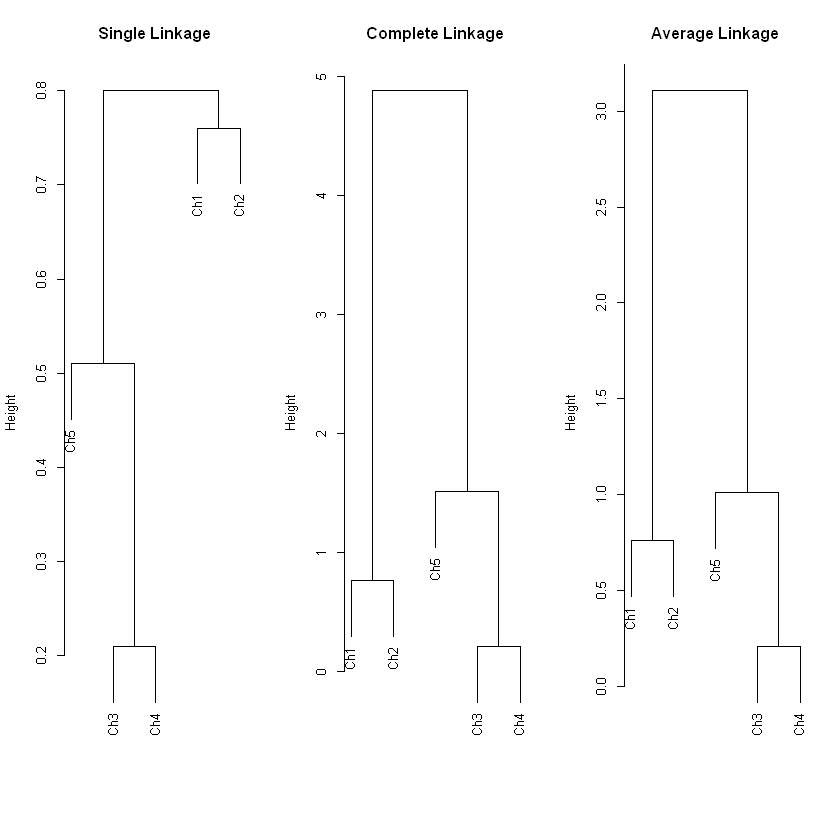

In [3]:
# perform agglomerative hierarchical clustering using single linkage, complete linkage, and average linkage
hc_single <- hclust(as.dist(D), method = "single")
hc_complete <- hclust(as.dist(D), method = "complete")
hc_average <- hclust(as.dist(D), method = "average")

# plot the dendrograms
par(mfrow = c(1, 3))
plot(hc_single, main = "Single Linkage", xlab = "", sub = "")
plot(hc_complete, main = "Complete Linkage", xlab = "", sub = "")
plot(hc_average, main = "Average Linkage", xlab = "", sub = "")

### b)

### Observations:
- Single linkage  height ranges upto $\approx$ 0.8
- Complete linkage height ranges upto $\approx$ 5
- Average linkage height ranges upto $\approx$ 3
- The comparative distance between 1 cluster and 2 cluster is heightest for Single linkage
- Complete linkage and Average linkage perform similar clusetering in this case

### c)

In [4]:
# Get 3 clusters from each dendrogram
clusters_single <- cutree(hc_single, k = 3)
clusters_complete <- cutree(hc_complete, k = 3)
clusters_average <- cutree(hc_average, k = 3)

# Print cluster assignments in a table format
cluster_table <- data.frame(
  Single_Linkage = clusters_single,
  Complete_Linkage = clusters_complete,
  Average_Linkage = clusters_average
)
print(cluster_table)

    Single_Linkage Complete_Linkage Average_Linkage
Ch1              1                1               1
Ch2              2                1               1
Ch3              3                2               2
Ch4              3                2               2
Ch5              3                3               3


### d)

- Single linkage forms long chains and nearest point merges. Hence, it performs different kind of clusters compared to other methods
- If points are sparse and clearly belonging to distinct clusters, complete linkage and average linkage perform similarly

### Problem 2

#### Comments:
- Standardizing the data as the scale of 100m, 200m is in seconds and Marathon has a significantly larger scale in minutes compared to other columns

In [5]:
path <- here("hw2", "data", "ladyrun25.dat")
ladyrun <- read.table(path)
colnames(ladyrun) <- c("Country","100m","200m","400m","800m","1500m","3000m","Marathon")

# standardize the data (except for the country names)
scaled_ladyrun <- ladyrun
scaled_ladyrun[,-1] <- scale(scaled_ladyrun[,-1], center = TRUE, scale = TRUE)

print(head(scaled_ladyrun, 5), row.names = FALSE)

 Country        100m        200m       400m       800m       1500m      3000m
     ARG -0.36051276 -0.14409453  0.2483053  0.3292503  0.04869993  0.1486980
     AUS -0.51461056 -0.92550673 -1.1652288 -0.5884021 -0.64527405 -0.5295264
     AUT -0.41187869 -0.40823386 -0.4383728 -0.9325218 -0.49917426 -0.3478592
     BEL -0.69439133 -0.95852415 -0.1352117 -0.5884021 -0.38959943 -0.2994146
     BER -0.07800012 -0.02303067  0.5405087  0.5586634  0.37742444  0.8995894
    Marathon
 -0.17951382
 -0.64349621
  0.06269461
 -0.61645060
  1.25450430


### a)

In [6]:
# compute all pairwise distances between the 25 countries using the Euclidean distance
D <- dist(scaled_ladyrun[,-1], method = "euclidean")

# print countries with the top 2 smallest and 2 largest distances along with country names
D_matrix <- as.matrix(D)
rownames(D_matrix) <- scaled_ladyrun$Country
colnames(D_matrix) <- scaled_ladyrun$Country
D_matrix_low <- D_matrix
D_matrix_low[lower.tri(D_matrix, diag = TRUE)] <- NA
D_table <- as.data.frame(as.table(D_matrix_low))
D_table <- D_table[!is.na(D_table$Freq), ]
colnames(D_table) <- c("Country1", "Country2", "Distance")
D_table <- D_table[order(D_table$Distance), ]

min_distances <- head(D_table, 2)
cat("\nCountries with the top 2 smallest distances along with country names:\n")
print(min_distances, row.names = FALSE)

max_distances <- tail(D_table, 2)
cat("\nCountries with the top 2 largest distances along with country names:\n")
print(max_distances, row.names = FALSE)


Countries with the top 2 smallest distances along with country names:
 Country1 Country2  Distance
      POR      SUI 0.3039506
      CRC      DOM 0.3451297

Countries with the top 2 largest distances along with country names:


 Country1 Country2 Distance
      SAM      USA 11.86853
      CHN      SAM 12.03103


### b)

In [7]:
cluster1_country <- scaled_ladyrun$Country[1]
cluster1_center <- scaled_ladyrun[1, -1]
cluster2_country <- scaled_ladyrun$Country[2]
cluster2_center <- scaled_ladyrun[2, -1]

# print previous cluster centers
cat("Previous cluster centers:\n")
cat('Cluster 1:\n')
print(cluster1_center, row.names = FALSE)
cat('Cluster 2:\n')
print(cluster2_center, row.names = FALSE)


Previous cluster centers:
Cluster 1:
       100m       200m      400m      800m      1500m    3000m   Marathon
 -0.3605128 -0.1440945 0.2483053 0.3292503 0.04869993 0.148698 -0.1795138
Cluster 2:
       100m       200m      400m       800m     1500m      3000m   Marathon
 -0.5146106 -0.9255067 -1.165229 -0.5884021 -0.645274 -0.5295264 -0.6434962


### b)i)

In [8]:
# for each country, find the closest cluster center
dist_to_cluster1 <- D_matrix[scaled_ladyrun$Country == cluster1_country, ]
dist_to_cluster2 <- D_matrix[scaled_ladyrun$Country == cluster2_country, ]

# assignment step: assign each country to the cluster with the closest center
closer_to_cluster1 <- dist_to_cluster1 <= dist_to_cluster2
closer_to_cluster2 <- dist_to_cluster2 < dist_to_cluster1

points_closer_to_cluster1 <- scaled_ladyrun[closer_to_cluster1, ]
points_closer_to_cluster2 <- scaled_ladyrun[closer_to_cluster2, ]

### b)ii)

In [9]:

# centroid update step: compute new cluster centers as the mean of the points assigned to each cluster
# mean points closer to each cluster, use only numeric features
cluster1_center_new <- colMeans(points_closer_to_cluster1[, -1], na.rm = TRUE)
cluster2_center_new <- colMeans(points_closer_to_cluster2[, -1], na.rm = TRUE)

cat("\n")
# print new cluster centers
cat("New cluster centers:\n")
cat('Cluster 1:\n')
print(cluster1_center_new, row.names = FALSE)
cat('Cluster 2:\n')
print(cluster2_center_new, row.names = FALSE)


New cluster centers:
Cluster 1:
     100m      200m      400m      800m     1500m     3000m  Marathon 
0.5693878 0.6221372 0.6432837 0.6219497 0.5902767 0.5366725 0.4857045 
Cluster 2:
      100m       200m       400m       800m      1500m      3000m   Marathon 
-0.6604898 -0.7216792 -0.7462091 -0.7214617 -0.6847210 -0.6225401 -0.5634172 


In [10]:
# compute the distance between all points to the new cluster centers
dist_to_cluster1_new <- apply(scaled_ladyrun[,-1], 1, function(x) sqrt(sum((x - cluster1_center_new)^2)))
dist_to_cluster2_new <- apply(scaled_ladyrun[,-1], 1, function(x) sqrt(sum((x - cluster2_center_new)^2)))

# find the closest cluster center for each point based on the new centers
closer_to_cluster1_new <- dist_to_cluster1_new <= dist_to_cluster2_new
closer_to_cluster2_new <- dist_to_cluster2_new < dist_to_cluster1_new

points_closer_to_cluster1_new <- scaled_ladyrun[closer_to_cluster1_new, ]
points_closer_to_cluster2_new <- scaled_ladyrun[closer_to_cluster2_new, ]

# print 4x4 distance matrix between old and new cluster centers
cat("\n")
cat("Distance matrix between old and new cluster centers:\n")
centers <- rbind(cluster1_center, cluster2_center, cluster1_center_new, cluster2_center_new)
center_distances <- dist(centers, method = "euclidean")
center_distances_matrix <- as.matrix(center_distances)
rownames(center_distances_matrix) <- c("Cluster 1 Old", "Cluster 2 Old", "Cluster 1 New", "Cluster 2 New")
colnames(center_distances_matrix) <- c("Cluster 1 Old", "Cluster 2 Old", "Cluster 1 New", "Cluster 2 New")
print(center_distances_matrix)


Distance matrix between old and new cluster centers:
              Cluster 1 Old Cluster 2 Old Cluster 1 New Cluster 2 New
Cluster 1 Old      0.000000     2.1520650      1.606192     1.9485228
Cluster 2 Old      2.152065     0.0000000      3.499198     0.5222347
Cluster 1 New      1.606192     3.4991975      0.000000     3.3352564
Cluster 2 New      1.948523     0.5222347      3.335256     0.0000000


### Observations:

- Cluster 1 center has moved significantly as can be observed by the distance between cluster 1 new and cluster 1 old
- Cluster 2 center has not moved much 
- Some points near the boundary of earlier clusters might update in the next iteration due to the move in Cluster 1 center

### c)

In [11]:
# compute within cluster sum of squares for the old clusters
wcss_cluster1_old <- sum(apply(points_closer_to_cluster1[, -1], 1, function(row){
    sum((row - cluster1_center)^2)
}))
wcss_cluster2_old <- sum(apply(points_closer_to_cluster2[, -1], 1, function(row){
    sum((row - cluster2_center)^2)
}))

total_wcss_old <- wcss_cluster1_old + wcss_cluster2_old
cat("\n")
cat("Total within cluster sum of squares for old clusters:", total_wcss_old, "\n")

# compute within cluster sum of squares for the new clusters
wcss_cluster1_new <- sum(apply(points_closer_to_cluster1_new[, -1], 1, function(row){
    sum((row - cluster1_center_new)^2)
}))
wcss_cluster2_new <- sum(apply(points_closer_to_cluster2_new[, -1], 1, function(row){
    sum((row - cluster2_center_new)^2)
}))
total_wcss_new <- wcss_cluster1_new + wcss_cluster2_new
cat("Total within cluster sum of squares for new clusters:", total_wcss_new, "\n")


Total within cluster sum of squares for old clusters: 303.2848 
Total within cluster sum of squares for new clusters: 202.8757 


### Observations:
- WCSS does not increase in our observation
- WCSS will decrease because for a given cluster assignment (which we determine in assignment step), the centroid of the cluster is the point which minimizes the WCSS for each cluster and thus, WCSS overall (WCSS overall is the sum of indivual cluster WCSS)

### d)

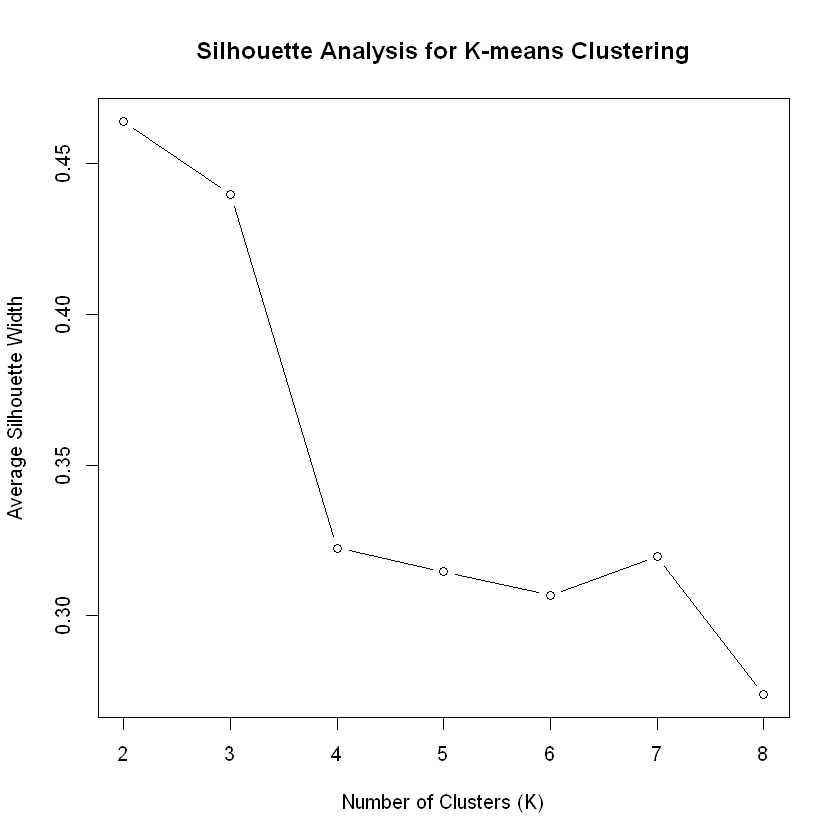

In [12]:
# run K-means for K=2 to 8 and plot average silhouette width for each K
library(cluster)
silhouette_widths <- numeric(7)
for (k in 2:8) {
    kmeans_result <- kmeans(scaled_ladyrun[,-1], centers = k, nstart = 25)
    silhouette_result <- silhouette(kmeans_result$cluster, dist(scaled_ladyrun[,-1]))
    silhouette_widths[k - 1] <- mean(silhouette_result[, 3])
}
plot(2:8, silhouette_widths, type = "b", xlab = "Number of Clusters (K)", ylab = "Average Silhouette Width", main = "Silhouette Analysis for K-means Clustering")

### Observations:

- K = 2 has the highest average silhouette width
- We want average silhouette width near 1 (well separated clusters)
- Hence, K = 2 is the best choice

### e)

In [13]:
library(mclust)

Package 'mclust' version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



#### Without Prior

In [14]:
# Fit Gaussian mixture models, allowing both the number of components K and the covariance structure to be selected by BIC.

# Fit GMM without using a prior
gmm_result_no_prior <- Mclust(
    scaled_ladyrun[, -1],
    G = 2:8,
    verbose = FALSE
)

cat("\n")
cat("Selected number of clusters K:", gmm_result_no_prior$G, "\n")
cat("Selected covariance model:", gmm_result_no_prior$modelName, "\n")

cluster_assignments <- gmm_result_no_prior$classification

smallest_clusters <- sort(table(cluster_assignments))[1:3]
cat("Countries in the three smallest clusters:\n")
for (cluster in names(smallest_clusters)) {
    cat(paste("Cluster", cluster, ":\n"))
    print(scaled_ladyrun$Country[cluster_assignments == as.numeric(cluster)], row.names = FALSE)
    cat("\n")
}

summary(gmm_result_no_prior)


Selected number of clusters K: 2 
Selected covariance model: EVE 
Countries in the three smallest clusters:
Cluster 1 :
 [1] "COL"  "COK"  "CRC"  "DOM"  "GUA"  "KORN" "MAS"  "PNG"  "SAM"  "SIN" 

Cluster 2 :
 [1] "ARG"  "AUS"  "AUT"  "BEL"  "BER"  "BRA"  "CAN"  "CHI"  "CHN"  "CZE" 
[11] "DEN"  "FIN"  "FRA"  "GER"  "GBR"  "GRE"  "HUN"  "INA"  "IND"  "IRL" 
[21] "ISR"  "ITA"  "JPN"  "KEN"  "KORS" "LUX"  "MRI"  "MEX"  "MYA"  "NED" 
[31] "NZL"  "NOR"  "PHI"  "POL"  "POR"  "ROM"  "RUS"  "ESP"  "SWE"  "SUI" 
[41] "TPE"  "THA"  "TUR"  "USA" 

Cluster NA :
 [1] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[26] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[51] NA NA NA NA



---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust EVE (ellipsoidal, equal volume and orientation) model with 2 components: 

 log-likelihood  n df       BIC       ICL
      -167.9707 54 49 -531.4016 -531.4914

Clustering table:
 1  2 
10 44 

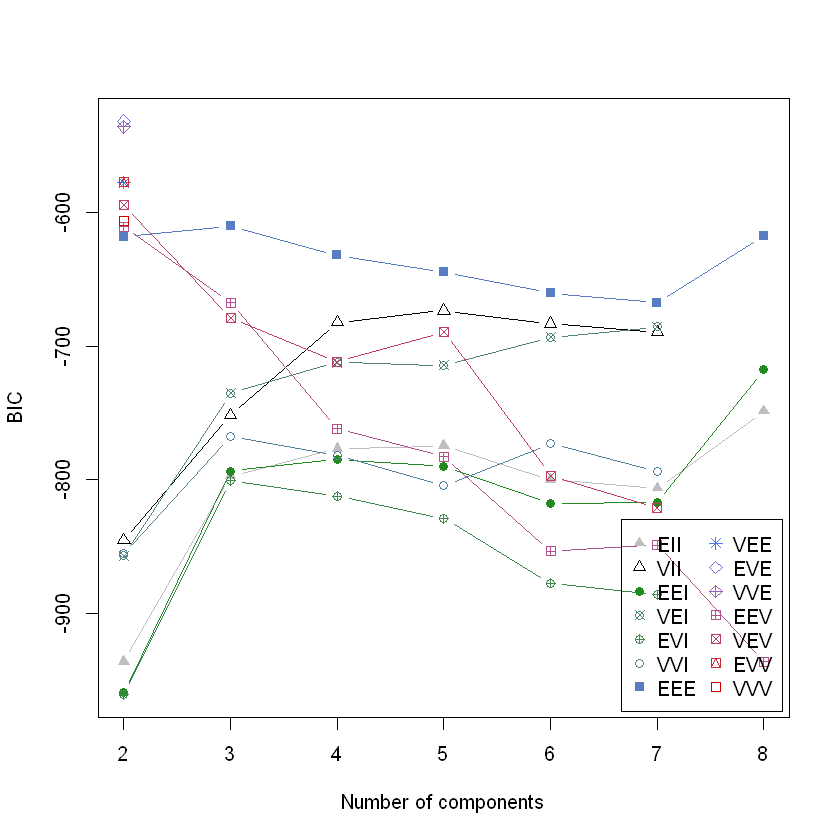

In [15]:
plot(gmm_result_no_prior, what = "BIC")

#### Comments:
Without prior, chosen covariance model is EVE.

For mclust EVE, the covariance for cluster $k$ is
$$\Sigma_k = \lambda\, D\, A_k\, D^T$$
where:
- $\lambda$ is common across clusters (equal volume),
- $D$ is common across clusters (equal orientation),
- $A_k$ varies by cluster (variable shape).

What that means in plain terms:
- Clusters are ellipsoids, not necessarily round balls.
- All clusters have the same overall volume.
- Clusters can have different axis ratios (shape can differ by cluster).
- All ellipsoids are aligned in the same orientation (no cluster-specific rotation).

#### With Prior

In [16]:
# Fit Gaussian mixture models, allowing both the number of components K and the covariance structure to be selected by BIC.
# Use a weakly informative conjugate prior to stabilize EM and reduce convergence issues
my_prior <- priorControl(
    functionName = "defaultPrior",
    shrinkage = 0.1
)

# Fit GMM with the specified prior
gmm_result_with_prior <- Mclust(
    scaled_ladyrun[, -1],
    G = 2:8,
    verbose = FALSE,
    prior = my_prior
)

cat("\n")
cat("Selected number of clusters K:", gmm_result_with_prior$G, "\n")
cat("Selected covariance model:", gmm_result_with_prior$modelName, "\n")

cluster_assignments <- gmm_result_with_prior$classification

smallest_clusters <- sort(table(cluster_assignments))[1:3]
cat("Countries in the three smallest clusters:\n")
for (cluster in names(smallest_clusters)) {
    cat(paste("Cluster", cluster, ":\n"))
    print(scaled_ladyrun$Country[cluster_assignments == as.numeric(cluster)], row.names = FALSE)
    cat("\n")
}
summary(gmm_result_with_prior)


Selected number of clusters K: 2 
Selected covariance model: VEV 
Countries in the three smallest clusters:
Cluster 1 :
 [1] "BER"  "CHI"  "COK"  "FRA"  "GUA"  "KORN" "MAS"  "MRI"  "NED"  "PNG" 
[11] "SAM"  "SIN"  "THA" 

Cluster 2 :
 [1] "ARG"  "AUS"  "AUT"  "BEL"  "BRA"  "CAN"  "CHN"  "COL"  "CRC"  "CZE" 
[11] "DEN"  "DOM"  "FIN"  "GER"  "GBR"  "GRE"  "HUN"  "INA"  "IND"  "IRL" 
[21] "ISR"  "ITA"  "JPN"  "KEN"  "KORS" "LUX"  "MEX"  "MYA"  "NZL"  "NOR" 
[31] "PHI"  "POL"  "POR"  "ROM"  "RUS"  "ESP"  "SWE"  "SUI"  "TPE"  "TUR" 
[41] "USA" 

Cluster NA :
 [1] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[26] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[51] NA NA NA NA



---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VEV (ellipsoidal, equal shape) model with 2 components: 

Prior: defaultPrior(shrinkage = 0.1) 

 log-likelihood  n df       BIC       ICL
      -168.9702 54 65 -597.2244 -600.2938

Clustering table:
 1  2 
13 41 

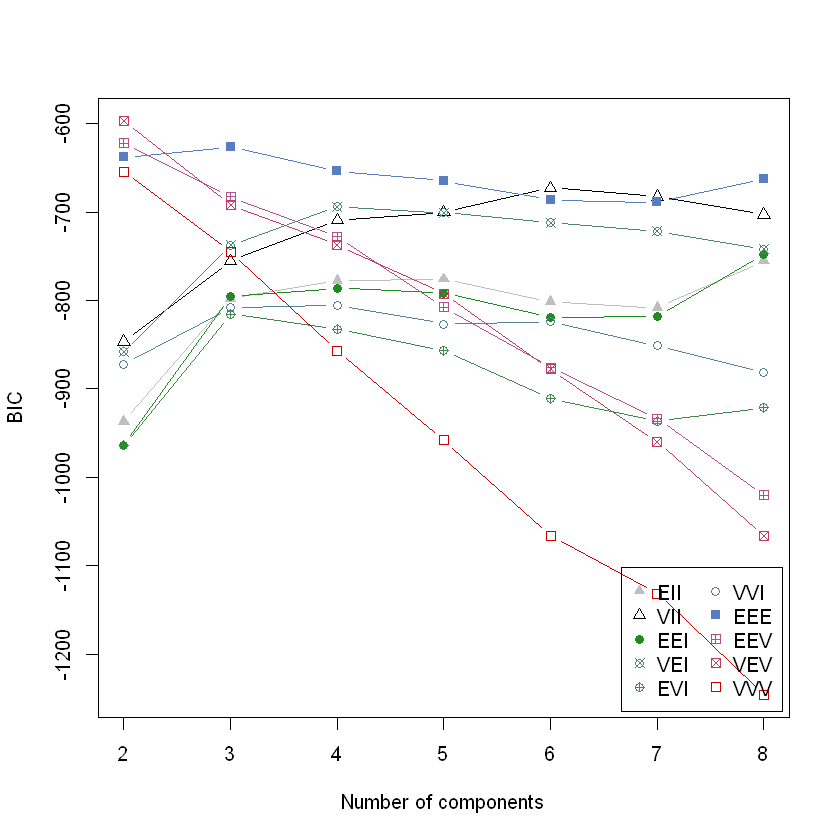

In [17]:
plot(gmm_result_with_prior, what = "BIC")

#### Comments:

With prior, the chosen covariance model is VEV.

For mclust VEV, the covariance for cluster $k$ is
$$\Sigma_k = \lambda_k\, D_k\, A\, D_k^T$$
where:
- $\lambda_k$ varies across clusters (variable volume),
- $A$ is common across clusters (equal shape),
- $D_k$ varies across clusters (variable orientation).

What that means in plain terms:
- Clusters are ellipsoids, not round balls.
- Cluster sizes (overall spread/volume) can differ.
- The axis ratios are shared across clusters (same shape).
- Clusters can rotate differently (orientation differs by cluster).

### f)

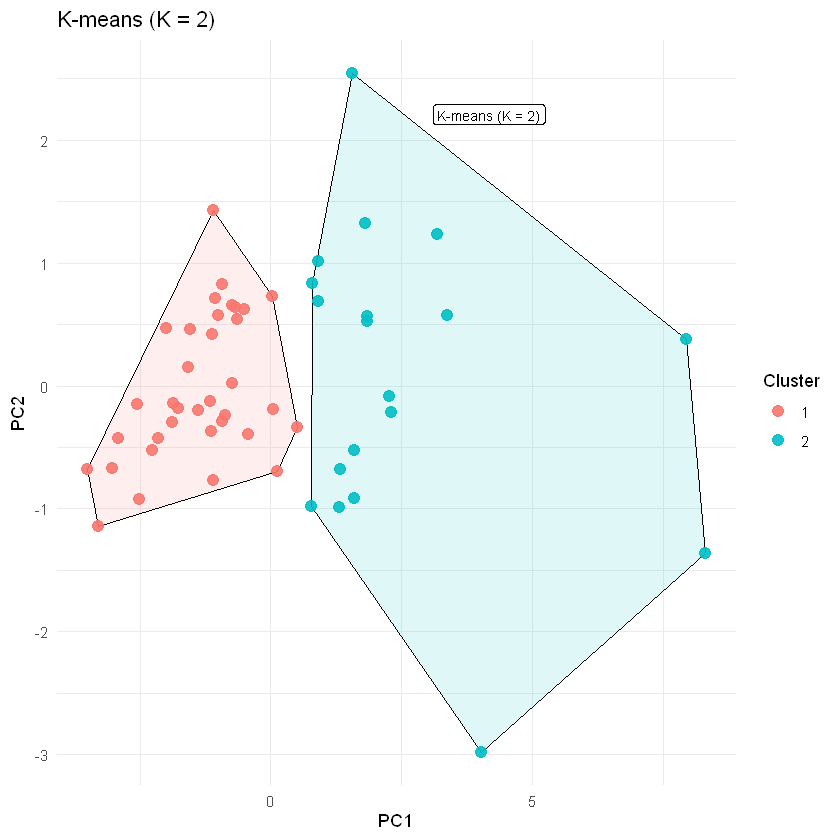

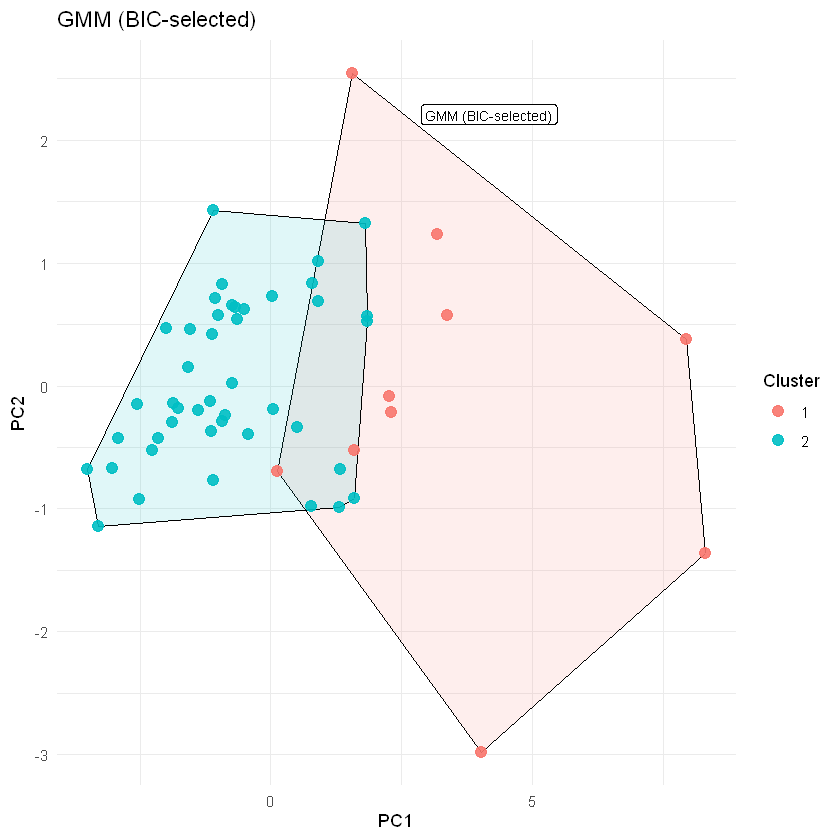

In [18]:
# Get the first 2 PCA components and compare K-means (K=5) vs GMM clusters
library(ggplot2)

X <- scaled_ladyrun[, -1]
pca_result <- prcomp(X, center = TRUE, scale. = TRUE)

# K-means with 5 clusters
set.seed(123)
kmeans_result <- kmeans(X, centers = 2, nstart = 25)

# Build plotting data for each method
plot_kmeans <- data.frame(
  PC1 = pca_result$x[, 1],
  PC2 = pca_result$x[, 2],
  Cluster = as.factor(kmeans_result$cluster)
 )

plot_gmm <- data.frame(
  PC1 = pca_result$x[, 1],
  PC2 = pca_result$x[, 2],
  Cluster = as.factor(gmm_result_no_prior$classification)
 )

make_cluster_plot <- function(df, panel_label, x_label_text) {
  # Convex-hull boundaries for each cluster
  hull_data <- do.call(
    rbind,
    lapply(split(df, df$Cluster), function(d) {
      if (nrow(d) < 3) return(NULL)
      d[chull(d$PC1, d$PC2), ]
    })
  )

  # Place one label inside each panel
  label_x <- min(df$PC1) + 0.65 * (max(df$PC1) - min(df$PC1))
  label_y <- max(df$PC2) - 0.06 * (max(df$PC2) - min(df$PC2))
  panel_text <- data.frame(PC1 = label_x, PC2 = label_y, Label = panel_label)

  ggplot(df, aes(x = PC1, y = PC2, color = Cluster)) +
    geom_polygon(
      data = hull_data,
      aes(x = PC1, y = PC2, group = Cluster, fill = Cluster),
      alpha = 0.12,
      color = "black",
      linewidth = 0.35,
      inherit.aes = FALSE,
      show.legend = FALSE
    ) +
    geom_point(size = 3, alpha = 0.9) +
    geom_label(
      data = panel_text,
      aes(x = PC1, y = PC2, label = Label),
      inherit.aes = FALSE,
      size = 3,
      linewidth = 0.2,
      fill = "white"
    ) +
    labs(
      title = panel_label,
      x = x_label_text,
      y = "PC2",
      color = "Cluster"
    ) +
    theme_minimal()
}

# Top plot: K-means
p_kmeans <- make_cluster_plot(
  plot_kmeans,
  panel_label = "K-means (K = 2)",
  x_label_text = "PC1"
 )
print(p_kmeans)

# Bottom plot: GMM
p_gmm <- make_cluster_plot(
  plot_gmm,
  panel_label = "GMM (BIC-selected)",
  x_label_text = "PC1"
 )
print(p_gmm)

In [19]:
# list the countries in each cluster for K-means and GMM that are different from each other. Compare cluster 1 in K-means to cluster 2 in GMM and cluster 2 in K-means to cluster 1 in GMM
kmeans_clusters <- split(scaled_ladyrun$Country, kmeans_result$cluster)
gmm_clusters <- split(scaled_ladyrun$Country, gmm_result_no_prior$classification)
cat("Countries in Cluster 1 of K-means and Cluster 2 of GMM:\n")
print(intersect(kmeans_clusters[[1]], gmm_clusters[[2]]), row.names = FALSE)
cat("\nCountries in Cluster 2 of K-means and Cluster 1 of GMM:\n")
print(intersect(kmeans_clusters[[2]], gmm_clusters[[1]]), row.names = FALSE)

# print those are different between the two methods
cat("\nCountries in Cluster 1 of K-means but not in Cluster 2 of GMM:\n")
print(setdiff(kmeans_clusters[[1]], gmm_clusters[[2]]), row.names = FALSE)
cat("\nCountries in Cluster 2 of K-means but not in Cluster 1 of GMM:\n")
print(setdiff(kmeans_clusters[[2]], gmm_clusters[[1]]), row.names = FALSE)

Countries in Cluster 1 of K-means and Cluster 2 of GMM:
 [1] "ARG" "AUS" "AUT" "BEL" "BRA" "CAN" "CHN" "CZE" "DEN" "FIN" "FRA" "GER"
[13] "GBR" "GRE" "HUN" "IND" "IRL" "ISR" "ITA" "JPN" "KEN" "MEX" "NED" "NZL"
[25] "NOR" "POL" "POR" "ROM" "RUS" "ESP" "SWE" "SUI" "TUR" "USA"

Countries in Cluster 2 of K-means and Cluster 1 of GMM:
[1] "COK"  "CRC"  "DOM"  "GUA"  "KORN" "MAS"  "PNG"  "SAM"  "SIN" 

Countries in Cluster 1 of K-means but not in Cluster 2 of GMM:
[1] "COL"

Countries in Cluster 2 of K-means but not in Cluster 1 of GMM:
 [1] "BER"  "CHI"  "INA"  "KORS" "LUX"  "MRI"  "MYA"  "PHI"  "TPE"  "THA" 


### Observations:
- The chosen GMM is EVE, which has equal volume, variable shape, equal orientation
- GMM allows for different variance for each cluster
- K-Means forces a single variance across clusters
- K-Means cluster looks well separated in PC1, PC2 subspace whereas GMM does not

### Problem 3

Dimension of the space is $\mathbb{R}^p$

$$p(x)=\sum_{k=1}^{K}\pi_k\phi_p(x|\mu_k,\Sigma_k) \tag1$$

$$\sum_{k=1}^{K}\pi_k=1 \quad , \quad \pi_k > 0 \tag2$$

$\pi_k$
- There are K $\pi_k$ and 1 constraint
- Total degrees of freedom (DoF) for $\pi_k = K-1$

$\mu_k$
- There are K $\mu_k$
- $\mu_k$ is a vector of dimension $\mathbb{R}^p$
- Total DoF for $\mu_k = K*p$

$\Sigma_k$
- There are K $\Sigma_k$
- For full covariance
    - There are $\frac{p(p+1)}{2}$ terms and degrees of freedom  for each k (as covariance matrix is symmetric)
    - Total DoF for $\Sigma_k$ = $K*\frac{p(p+1)}{2}$
- For diagonal covariance where diagonal terms can be different
    - There are $p$ DoF for each k
    - Total DoF for $\Sigma_k$ = $K*p$
- For spherical covariance $\sigma_{k}^2 I$
    - There is only $1$ DoF for each k
    - Total DoF for $\Sigma_k$ = $K$
- If any parameter is shared across clusters, we divide the degrees of freedom by K
    - Total DoF for $\Sigma_k$ for shared full covariance = $\frac{p(p+1)}{2}$
    - Total DoF for $\Sigma_k$ for shared diagonal covariance = $p$
    - Total DoF for $\Sigma_k$ for shared spherical covariance = $1$

### a)

(i) full covariance by component ($\Sigma_k$ unrestricted and distinct)
$$DoF = K-1 + K*p + K*\frac{p(p+1)}{2}$$

(ii) shared full covariance ($\Sigma_k = \Sigma$ for all k)
$$DoF = K-1 + K*p + \frac{p(p+1)}{2}$$

(iii) diagonal covariance by component
$$DoF = K-1 + K*p + K*p$$

(iv) spherical covariance by component ($\Sigma_k = \sigma_{k}^2 I_p$)
$$DoF = K-1 + K*p + K$$

### b)

Given,

$$\Sigma_i = \Sigma \quad,\: for \,all\,i$$

$$\Theta^{(t)} = \{\pi^{(t)},\mu^{(t)},\Sigma^{(t)}\}_{k=1}^K$$

Responsibilities,
$$\gamma_{ik}^{(t)}=Pr(Z_i=k|x_i,\Theta^{(t)})$$

Applying bayes rule,
$$Pr(Z_i=k|x_i,\Theta^{(t)}) = \frac{Pr(Z_i=k,x_i|\Theta^{(t)})}{Pr(x_i|\Theta^{(t)})}$$

$$Pr(Z_i=k,x_i|\Theta^{(t)}) = Pr(x_i|Z_i=k,\Theta^{(t)})Pr(Z_i=k|\Theta^{(t)})$$

$$Pr(x_i|Z_i=k,\Theta^{(t)}) = \phi_p(x_i|\mu_k^{(t)},\Sigma^{(t)})$$

$$Pr(Z_i=k|\Theta^{(t)}) = \pi_k^{(t)}$$


Therefore,

$$\gamma_{ik}^{(t)}=\frac{\pi_k^{(t)}\phi_p(x_i|\mu_k^{(t)},\Sigma^{(t)})}{\sum_{k=1}^{K}\pi_k^{(t)}\phi_p(x_i|\mu_k^{(t)},\Sigma^{(t)})}$$

where,

$$\phi_p \sim Normal\:distribution$$

### c)

In the M-step, we maximize expected complete-data log-likelihood

$$Q(\Theta \mid \Theta^{(t)}) = E_{Z \mid X, \Theta^{(t)}} [\log p(X, Z \mid \Theta)]$$

For all $x_i$ assuming independence, we can write $p(X, Z \mid \Theta)$ as product of probabilities for each $x_i$. Under logarithm, product becomes sum.

For a particular value of $Z_i$
$$\log p(X, Z_i \mid \Theta) = \sum_{i=1}^{n} [\log \pi_{Z_i} + \log \phi_p(x_i \mid \mu_{Z_i}, \Sigma)]$$

From E-step, we know the distribution of $(Z \mid X,\Theta^{(t)})$. Taking expectation under this distribution gives
$$Q(\Theta \mid \Theta^{(t)}) = \sum_{k=1}^{K} \sum_{i=1}^{n}  \gamma_{ik}^{(t)} [\log \pi_k + \log \phi_p(x_i \mid \mu_k, \Sigma)]$$

$$\log \phi_p(x_i \mid \mu_k, \Sigma) = -\frac{1}{2} \log |\Sigma| - \frac{1}{2} (x_i - \mu_k)^T \Sigma^{-1} (x_i - \mu_k) + \text{const.}$$

Define the effective membership counts
$$N_k^{(t)} = \sum_{i=1}^{n} \gamma_{ik}^{(t)}$$

Keeping only terms that depend on parameters,
$$Q(\Theta \mid \Theta^{(t)}) = \sum_{k=1}^{K}\sum_{i=1}^{n}\gamma_{ik}^{(t)}\log\pi_k - \frac{1}{2}\sum_{k=1}^{K}\sum_{i=1}^{n}\gamma_{ik}^{(t)}\left[\log|\Sigma| + (x_i-\mu_k)^T\Sigma^{-1}(x_i-\mu_k)\right] + C$$

For mixing proportions, maximize
$$\sum_{k=1}^{K} N_k^{(t)}\log\pi_k \quad \text{s.t.}\quad \sum_{k=1}^{K}\pi_k=1$$

Using a Lagrange multiplier gives
$$\pi_k^{(t+1)} = \frac{N_k^{(t)}}{n}$$

For means, differentiate w.r.t. $\mu_k$ and set to zero:
$$\frac{\partial Q}{\partial \mu_k} = \Sigma^{-1}\sum_{i=1}^{n}\gamma_{ik}^{(t)}(x_i-\mu_k)=0$$
$$\Rightarrow \mu_k^{(t+1)} = \frac{1}{N_k^{(t)}}\sum_{i=1}^{n}\gamma_{ik}^{(t)}x_i$$

For the shared full covariance, use
$$S = \sum_{k=1}^{K}\sum_{i=1}^{n}\gamma_{ik}^{(t)}(x_i-\mu_k^{(t+1)})(x_i-\mu_k^{(t+1)})^T$$

Then the covariance part is
$$Q_{\Sigma}= -\frac{1}{2}\left[\left(\sum_{k=1}^{K}\sum_{i=1}^{n}\gamma_{ik}^{(t)}\right)\log|\Sigma| + \mathrm{tr}(\Sigma^{-1}S)\right] + C$$

Since $\sum_{k=1}^{K}\sum_{i=1}^{n}\gamma_{ik}^{(t)} = n$, setting derivative to zero gives
$$\Sigma^{(t+1)} = \frac{1}{n}\sum_{k=1}^{K}\sum_{i=1}^{n}\gamma_{ik}^{(t)}(x_i-\mu_k^{(t+1)})(x_i-\mu_k^{(t+1)})^T$$

Hence, the M-step updates for the shared full covariance model are
$$\pi_k^{(t+1)} = \frac{N_k^{(t)}}{n},\qquad \mu_k^{(t+1)} = \frac{\sum_{i=1}^{n}\gamma_{ik}^{(t)}x_i}{N_k^{(t)}},\qquad \Sigma^{(t+1)} = \frac{1}{n}\sum_{k=1}^{K}\sum_{i=1}^{n}\gamma_{ik}^{(t)}(x_i-\mu_k^{(t+1)})(x_i-\mu_k^{(t+1)})^T$$

### d)

- Full covariance by component allows more degrees of freedom in choosing clusters as each cluster can have different size, orientation and shape along different dimensions
- Shared full covariance is comparatively respectively as the covariance matrix is shared by all the clusters. It enforces that all clusters have similar shape distribution and can lead to few clusters merging to form bigger clusters and may underfit the data
- Because of more DoF, full covariance by component will likely predict higher number of distinct clusters and may overfit the data
- Computationally, shared full covariance is cheaper as we are calculating fewer parameters and typically more numerically stable in EM/BIC search

### Problem 4

### a)

Let $X \in \mathbb{R}^p$ be the centered and standardized random vector

Therefore,

$$ \mathbb{E}[X_i] = 0 $$
$$ Var(X_i) = 1$$

Let $ Z = v^TX$ be the first PC with eigenvalue $\lambda$

$$ Var(Z) = v^T\Sigma v $$
$$ \Sigma v = \lambda v $$
$$ Var(Z) = v^T (\lambda v) = \lambda v^Tv = \lambda $$


$v = (v_1,v_2,...,v_p)^T \quad; \; v_i = weight \: corresponding \: to \: X_i$

Therefore,

$$ Z = \sum_{i=1}^p v_iX_i$$

$$ Cov(X_j,Z) = Cov(X_j,\sum_{i=1}^p v_iX_i) $$
$$ = \sum_{i=1}^p v_i Cov(X_j, X_i) $$
$$ = \sum_{i=1}^p v_i E[X_jX_i] $$
$$ = \sum_{i=1}^p v_i \Sigma_{i,j} $$
$$ = (\Sigma v)_j $$
$$ = \lambda v_j $$

$$ Corr(X_j,Z) = \frac{Cov(X_j,Z)}{\sqrt{Var(X_j)Var(Z)}} = \sqrt{\lambda}v_j $$

### b)

$$ U = a^TX = \sum_{i=1}^p a_iX_i $$
$$ Var(U) = 1 $$
$$ Cov(X,U) = XU^T = XX^Ta = \Sigma_{XX}a $$

$$ Cov(X_j,U) = Cov(X_j, \sum_{i=1}^p a_iX_i) $$
$$ = \sum_{i=1}^p a_i Cov(X_j, X_i) $$
$$ = \sum_{i=1}^p a_i E[X_jX_i] $$
$$ = \sum_{i=1}^p a_i \Sigma_{XX_{i,j}} $$
$$ = (\Sigma_{XX} a)_j $$

$$ Corr(X_j,U) = \frac{Cov(X_j,U)}{\sqrt{Var(X_j)Var(U)}} = (\Sigma_{XX} a)_j $$

Since $a$ is not the eigenvector of $\Sigma_{XX}$, we are not able to write it in terms of $a_j$ (as we did in PCA case).

Hence, loadings are not proportional to the weights $a_j$.

### c)

Let $p=2$ and define
$$\Sigma_{XX}=\begin{pmatrix}1 & 0.95\\ 0.95 & 1\end{pmatrix},\qquad a=\begin{pmatrix}0.1\\ 1\end{pmatrix}. $$
Consider $U=a^TX=0.1X_1+1\cdot X_2$ (up to a scale normalization for unit variance).
The weight on $X_1$ is small ($a_1=0.1$), but its loading is
$$\mathrm{Corr}(X_1,U)=\frac{(\Sigma_{XX}a)_1}{\sqrt{\mathrm{Var}(X_1)\,\mathrm{Var}(U)}}=\frac{1\cdot0.1+0.95\cdot1}{\sqrt{a^T\Sigma_{XX}a}}=\frac{1.05}{\sqrt{1.195}}\approx 0.959.$$
So despite the small direct weight on $X_1$, strong correlation with $X_2$ makes its loading large.

In [20]:
# Concrete p = 2 example: small weight on X1, but large loading Corr(X1, U)
Sigma <- matrix(c(1, 0.95,
                  0.95, 1), nrow = 2, byrow = TRUE)
a <- c(0.1, 1)
names(a) <- c("X1", "X2")

# U = a^T X (not yet normalized)
var_U <- as.numeric(t(a) %*% Sigma %*% a)
cov_XU <- Sigma %*% a
loadings <- as.numeric(cov_XU / sqrt(diag(Sigma) * var_U))
names(loadings) <- c("Corr(X1, U)", "Corr(X2, U)")

cat("Sigma:\n")
print(Sigma)
cat("\na:\n")
print(a)
cat("\nVar(U) =", var_U, "\n")
cat("\nCov(X, U) = Sigma %*% a:\n")
print(cov_XU)
cat("\nLoadings Corr(Xj, U):\n")
print(loadings)

cat("\nKey check: a1 =", a["X1"], "(small), but Corr(X1, U) =", round(loadings["Corr(X1, U)"], 3), "(large).\n")

Sigma:
     [,1] [,2]
[1,] 1.00 0.95
[2,] 0.95 1.00

a:
 X1  X2 
0.1 1.0 

Var(U) = 1.2 

Cov(X, U) = Sigma %*% a:
      [,1]
[1,] 1.050
[2,] 1.095

Loadings Corr(Xj, U):
Corr(X1, U) Corr(X2, U) 
  0.9585145   0.9995937 

Key check: a1 = 0.1 (small), but Corr(X1, U) = 0.959 (large).


### Problem 5

In [21]:
stiffness <- read.table(here("hw2", "data", "stiffness.DAT"), header = FALSE)

colnames(stiffness) <- c("X1", "X2", "Y1", "Y2", "Dist")

X = stiffness[,1:2]
Y = stiffness[,3:4]

print(head(stiffness, 5), row.names = FALSE)

   X1   X2   Y1   Y2 Dist
 1889 1651 1561 1778 0.60
 2403 2048 2087 2197 5.48
 2119 1700 1815 2222 7.62
 1645 1627 1110 1533 5.21
 1976 1916 1614 1883 1.40


In [22]:
library(CCA)

Loading required package: fda

Loading required package: splines

Loading required package: fds

Loading required package: rainbow

Loading required package: MASS

Loading required package: pcaPP

Loading required package: RCurl

Loading required package: deSolve


Attaching package: 'fda'


The following object is masked from 'package:graphics':

    matplot


The following object is masked from 'package:datasets':

    gait


Loading required package: fields

Loading required package: spam

Spam version 2.11-3 (2026-01-05) is loaded.
Type 'help( Spam)' or 'demo( spam)' for a short introduction 
and overview of this package.
Help for individual functions is also obtained by adding the
suffix '.spam' to the function name, e.g. 'help( chol.spam)'.


Attaching package: 'spam'


The following objects are masked from 'package:base':

    backsolve, forwardsolve


Loading required package: viridisLite

Loading required package: RColorBrewer


Try help(fields) to get started.



### a)

In [23]:
# perform CCA on X and Y
cca_result <- cc(X, Y)
cat("\nCanonical correlations:\n")
print(cca_result$cor, row.names = FALSE)


Canonical correlations:
[1] 0.91291935 0.06805556


### b)

In [24]:
print(cca_result$xcoef[, 1])

           X1            X2 
-0.0036015621  0.0005957354 


In [25]:
print(cca_result$ycoef[, 1])

          Y1           Y2 
-0.001344804 -0.001893392 


$$U1 = -0.0036015621*X_1 + 0.0005957354*X_2$$
$$V1 = -0.001344804*Y_1 + (-0.001893392)*Y_2$$

In [26]:
# compute the canonical variates for the first pair of canonical variables
U1 <- as.matrix(X) %*% cca_result$xcoef[, 1]
V1 <- as.matrix(Y) %*% cca_result$ycoef[, 1]

cat("\nFirst pair of canonical variates (U1 and V1):\n")
print(head(data.frame(U1 = U1, V1 = V1), n = 6), row.names = FALSE)


First pair of canonical variates (U1 and V1):
        U1        V1
 -5.819792 -5.465690
 -7.434488 -6.966388
 -6.618960 -6.647936
 -4.955308 -4.395302
 -5.975258 -5.735771
 -5.145975 -4.862357


### c)

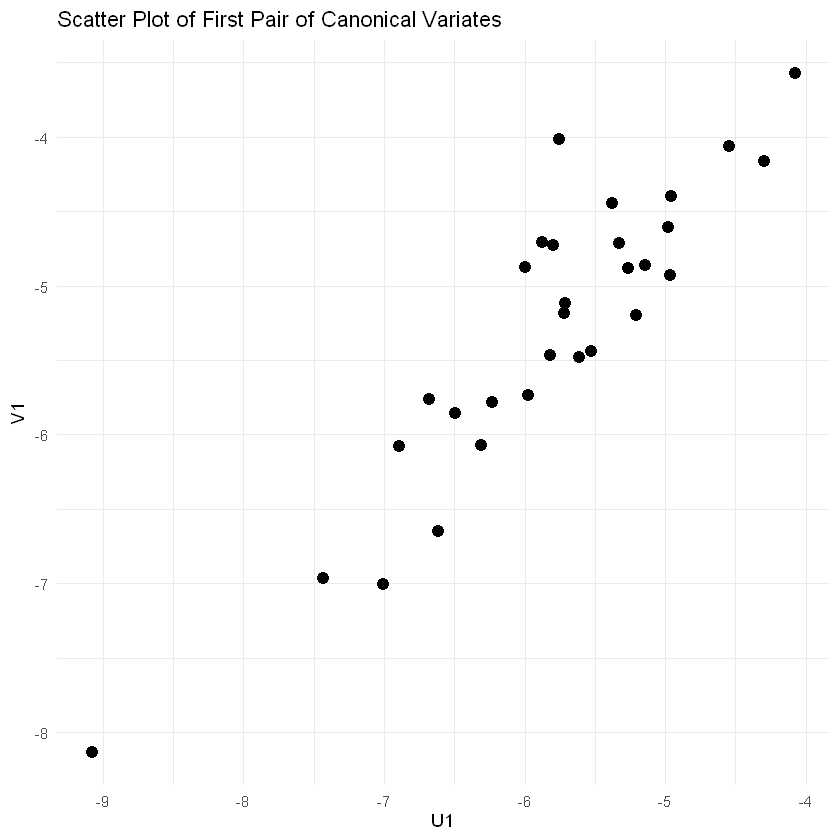

In [27]:
# produce scatter plot of U1 vs V1
ggplot(data.frame(U1 = U1, V1 = V1), aes(x = U1, y = V1)) +
  geom_point(size = 3) +
  labs(title = "Scatter Plot of First Pair of Canonical Variates", x = "U1", y = "V1") +
  theme_minimal()

- U1 and V1 show strong linear correlation as the scores of X and Y along U1 and V1 seem to lie along a line

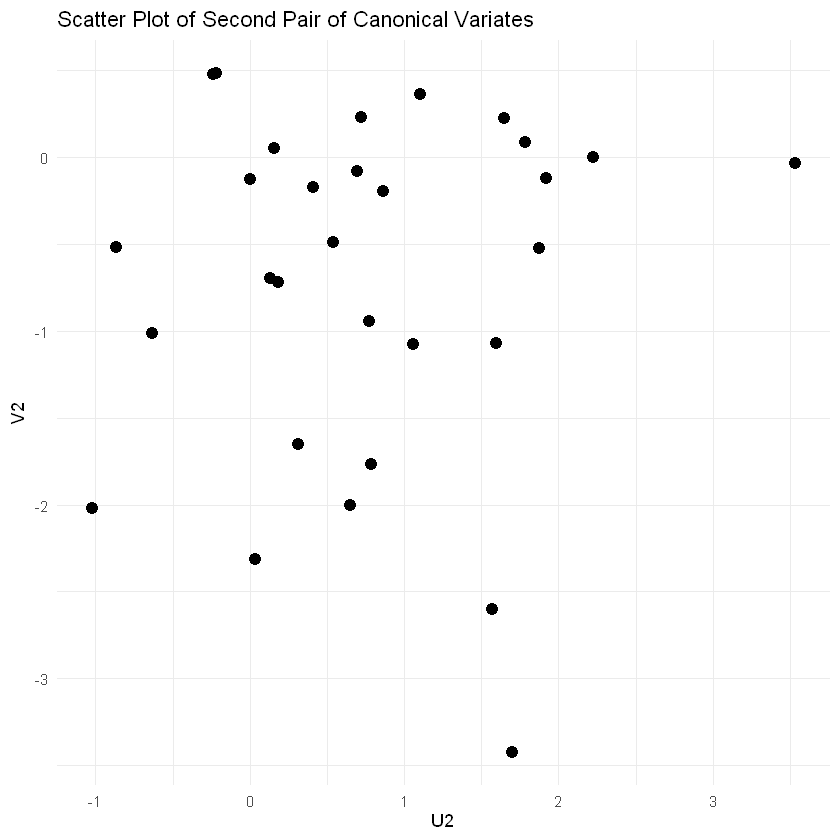

In [28]:
U2 <- as.matrix(X) %*% cca_result$xcoef[, 2]
V2 <- as.matrix(Y) %*% cca_result$ycoef[, 2]

# produce scatter plot of U2 vs V2
ggplot(data.frame(U2 = U2, V2 = V2), aes(x = U2, y = V2)) +
  geom_point(size = 3) +
  labs(title = "Scatter Plot of Second Pair of Canonical Variates", x = "U2", y = "V2") +
  theme_minimal()

- There is no apparent structure that can be inferred visually from the scores of X and Y along U2 and V2 respectively

### d)

In [29]:
# compute the correlations between the original variables and the first pair of canonical variates
cor_X_U1 <- cor(X, U1)
rownames(cor_X_U1) <- c('X1', 'X2')
colnames(cor_X_U1) <- "Corr(X, U1)"
cor_Y_V1 <- cor(Y, V1)
rownames(cor_Y_V1) <- c('Y1', 'Y2')
colnames(cor_Y_V1) <- "Corr(Y, V1)"
cat("\nCorrelations between original variables and first pair of canonical variate with proper labels:\n")
print(cor_X_U1, row.names = TRUE)
print(cor_Y_V1, row.names = TRUE)


Correlations between original variables and first pair of canonical variate with proper labels:
   Corr(X, U1)
X1  -0.9970227
X2  -0.8797163
   Corr(Y, V1)
Y1   -0.971979
Y2   -0.987632


In [30]:
# print correlation matrix of X
cat("\nCorrelation matrix of X:\n")
print(cor(X), row.names = TRUE)

# print correlation matrix of Y
cat("\nCorrelation matrix of Y:\n")
print(cor(Y), row.names = TRUE)


Correlation matrix of X:
         X1       X2
X1 1.000000 0.913762
X2 0.913762 1.000000

Correlation matrix of Y:
          Y1        Y2
Y1 1.0000000 0.9231013
Y2 0.9231013 1.0000000


### Observations:

U1:
- The direction U1 is strongly correlated to both X1 and X2, with higher correlation to X1
- This is as expected as X1 and X2 are highly correlated with each other ($\approx 91.4%$)
- Although weights were very low, absolute correlations are near 1 which shows that weights can be looked at in insolation for CCA
- The sign of weights for X1 and X2 were opposite whereas U1 has same direction loading for both X1 and X2

V1:
- The direction V1 is strongly correlated to both Y1 and Y2, with higher correlation to Y2
- This is as expected as Y1 and Y2 are highly correlated with each other ($\approx 92.3%$)
- Although weights were very low, absolute correlations are near 1 which shows that weights can be looked at in insolation for CCA

### e)

In [31]:
# perform CCA 20 times with train-test split of 70-30 and compute the correlations between the original variables and the first pair of canonical variates for each run on test set, then report the average and standard deviation of these correlations across the 20 runs
set.seed(123)
num_runs <- 20
cor_X_U1_list <- matrix(NA, nrow = num_runs, ncol = ncol(X))
cor_Y_V1_list <- matrix(NA, nrow = num_runs, ncol = ncol(Y))
cor_X_U2_list <- matrix(NA, nrow = num_runs, ncol = ncol(X))
cor_Y_V2_list <- matrix(NA, nrow = num_runs, ncol = ncol(Y))
for (i in 1:num_runs) {
  # create train-test split
  sample_indices <- sample(1:nrow(X), size = 0.7 * nrow(X), replace = FALSE)
  X_train <- X[sample_indices, ]
  Y_train <- Y[sample_indices, ]
  X_test <- X[-sample_indices, ]
  Y_test <- Y[-sample_indices, ]
  
  # perform CCA on training data
  cca_result_train <- cc(X_train, Y_train)
  
  # compute canonical variates for test data using coefficients 1 from training CCA
  U1_test <- as.matrix(X_test) %*% cca_result_train$xcoef[, 1]
  V1_test <- as.matrix(Y_test) %*% cca_result_train$ycoef[, 1]
  
  # compute correlations between original variables and first pair of canonical variates on test set
  cor_X_U1_list[i, ] <- cor(X_test, U1_test)
  colnames(cor_X_U1_list) <- colnames(X)
  cor_Y_V1_list[i, ] <- cor(Y_test, V1_test)
  colnames(cor_Y_V1_list) <- colnames(Y)

  # compute canonical variates for test data using coefficients 2 from training CCA
  U2_test <- as.matrix(X_test) %*% cca_result_train$xcoef[, 2]
  V2_test <- as.matrix(Y_test) %*% cca_result_train$ycoef[, 2]

  # compute correlations between original variables and second pair of canonical variates on test set
  cor_X_U2_list[i, ] <- cor(X_test, U2_test)
  colnames(cor_X_U2_list) <- colnames(X)
  cor_Y_V2_list[i, ] <- cor(Y_test, V2_test)
  colnames(cor_Y_V2_list) <- colnames(Y)
}

In [32]:
avg_cor_X_U1 <- colMeans(cor_X_U1_list)
sd_cor_X_U1 <- apply(cor_X_U1_list, 2, sd)
avg_cor_Y_V1 <- colMeans(cor_Y_V1_list)
sd_cor_Y_V1 <- apply(cor_Y_V1_list, 2, sd)
avg_cor_X_U2 <- colMeans(cor_X_U2_list)
sd_cor_X_U2 <- apply(cor_X_U2_list, 2, sd)
avg_cor_Y_V2 <- colMeans(cor_Y_V2_list)
sd_cor_Y_V2 <- apply(cor_Y_V2_list, 2, sd)
cat("\nAverage correlations between original variables and first pair of canonical variate across 20 runs:\n")
print(avg_cor_X_U1, row.names = TRUE)
print(avg_cor_Y_V1, row.names = TRUE)
cat("\nStandard deviation of correlations between original variables and first pair of canonical variate across 20 runs:\n")
print(sd_cor_X_U1, row.names = TRUE)
print(sd_cor_Y_V1, row.names = TRUE)
cat("\nAverage correlations between original variables and second pair of canonical variate across 20 runs:\n")
print(avg_cor_X_U2, row.names = TRUE)
print(avg_cor_Y_V2, row.names = TRUE)
cat("\nStandard deviation of correlations between original variables and second pair of canonical variate across 20 runs:\n")
print(sd_cor_X_U2, row.names = TRUE)
print(sd_cor_Y_V2, row.names = TRUE)


Average correlations between original variables and first pair of canonical variate across 20 runs:
        X1         X2 
-0.9862704 -0.8742489 
        Y1         Y2 
-0.9671796 -0.9793782 

Standard deviation of correlations between original variables and first pair of canonical variate across 20 runs:
        X1         X2 
0.02967228 0.07562165 
        Y1         Y2 
0.02933482 0.02277526 

Average correlations between original variables and second pair of canonical variate across 20 runs:
         X1          X2 
-0.03059727  0.36525682 
         Y1          Y2 
 0.22962203 -0.03931484 

Standard deviation of correlations between original variables and second pair of canonical variate across 20 runs:
       X1        X2 
0.4620722 0.3598319 
       Y1        Y2 
0.3914237 0.4925821 


### f)

In [33]:
# Plot boxplots on correlations range -1 to 0.5 with breaks at every 0.1 for both first and second pair of canonical variates
y_lim <- c(-1, 0.5)
y_breaks <- seq(-1, 0.5, by = 0.1)

No id variables; using all as measure variables

No id variables; using all as measure variables



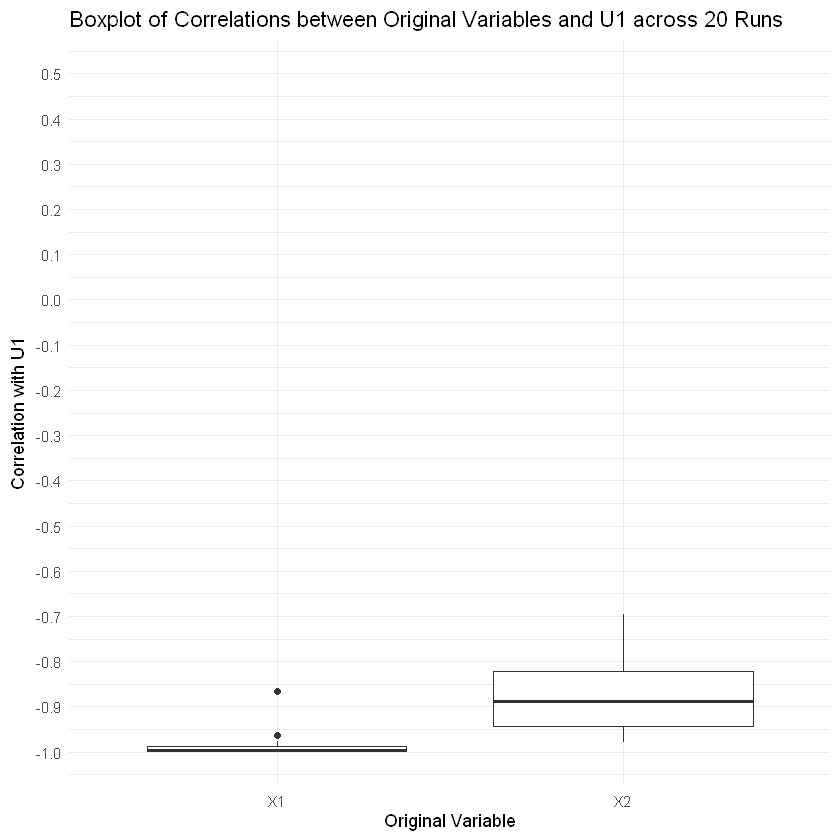

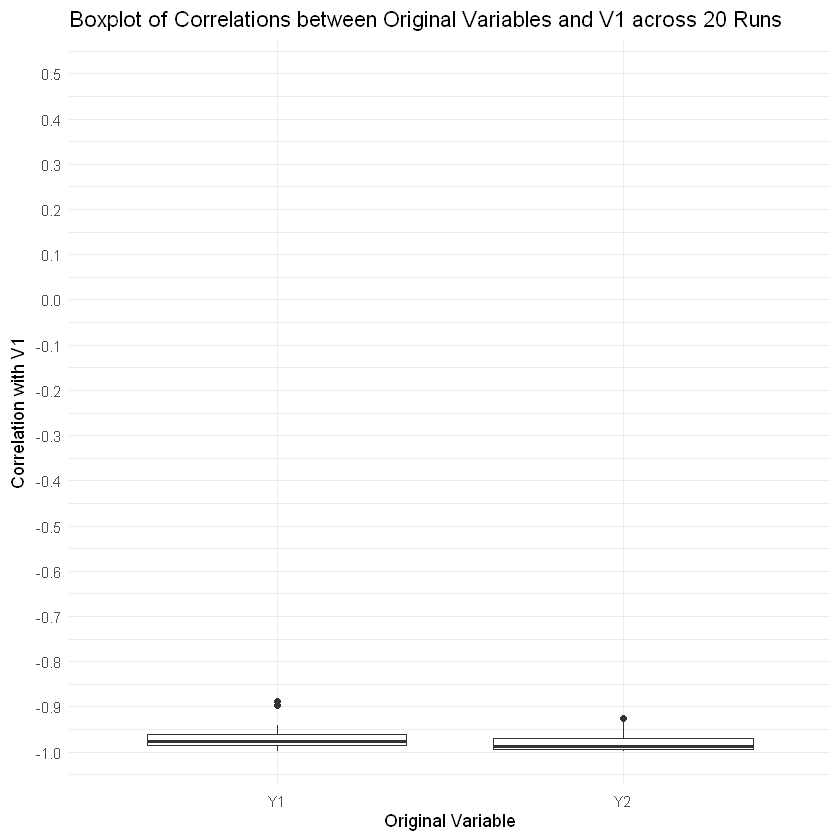

In [34]:
# plot boxplots of the correlations between original variables and first pair of canonical variates across the 20 runs
cor_X_U1_df <- data.frame(cor_X_U1_list)
colnames(cor_X_U1_df) <- colnames(X)
cor_Y_V1_df <- data.frame(cor_Y_V1_list)
colnames(cor_Y_V1_df) <- colnames(Y)
cor_X_U1_df_melt <- reshape2::melt(cor_X_U1_df, variable.name = "Variable", value.name = "Correlation")
cor_Y_V1_df_melt <- reshape2::melt(cor_Y_V1_df, variable.name = "Variable", value.name = "Correlation")
ggplot(cor_X_U1_df_melt, aes(x = Variable, y = Correlation)) +
  geom_boxplot() +
  scale_y_continuous(limits = y_lim, breaks = y_breaks) +
  labs(title = "Boxplot of Correlations between Original Variables and U1 across 20 Runs", x = "Original Variable", y = "Correlation with U1") +
  theme_minimal()
ggplot(cor_Y_V1_df_melt, aes(x = Variable, y = Correlation)) +
  geom_boxplot() +
  scale_y_continuous(limits = y_lim, breaks = y_breaks) +
  labs(title = "Boxplot of Correlations between Original Variables and V1 across 20 Runs", x = "Original Variable", y = "Correlation with V1") +
  theme_minimal()

### Observations:
- The first pair of canonical loadings are stable across different train-test splits with low variance and are robust
- This shows that the relationship persists out of sample and can be generalized

No id variables; using all as measure variables

No id variables; using all as measure variables

Warning message:
"Removed 10 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 10 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


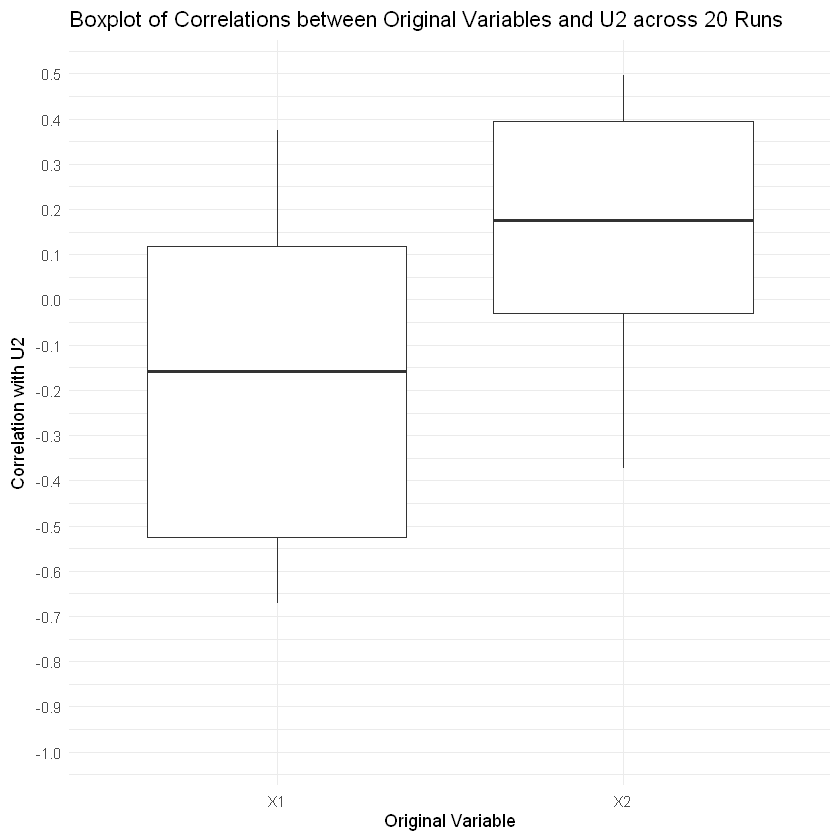

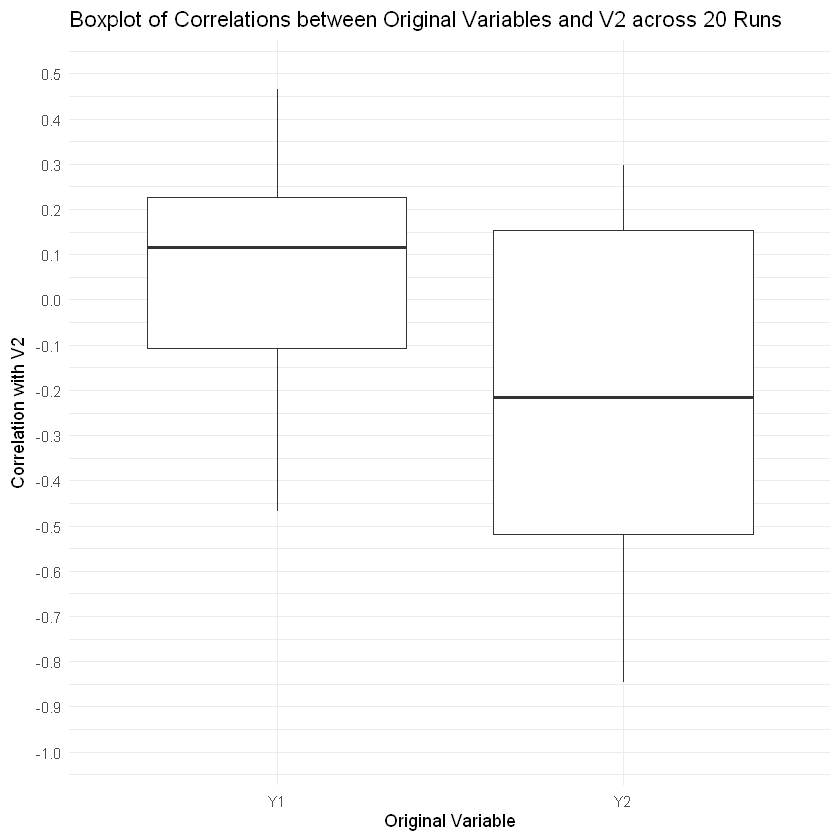

In [35]:
# plot boxplots of the correlations between original variables and second pair of canonical variates across the 20 runs
cor_X_U2_df <- data.frame(cor_X_U2_list)
colnames(cor_X_U2_df) <- colnames(X)
cor_Y_V2_df <- data.frame(cor_Y_V2_list)
colnames(cor_Y_V2_df) <- colnames(Y)
cor_X_U2_df_melt <- reshape2::melt(cor_X_U2_df, variable.name = "Variable", value.name = "Correlation")
cor_Y_V2_df_melt <- reshape2::melt(cor_Y_V2_df, variable.name = "Variable", value.name = "Correlation")
ggplot(cor_X_U2_df_melt, aes(x = Variable, y = Correlation)) +
  geom_boxplot() +
  scale_y_continuous(limits = y_lim, breaks = y_breaks) +
  labs(title = "Boxplot of Correlations between Original Variables and U2 across 20 Runs", x = "Original Variable", y = "Correlation with U2") +
  theme_minimal()
ggplot(cor_Y_V2_df_melt, aes(x = Variable, y = Correlation)) +
  geom_boxplot() +
  scale_y_continuous(limits = y_lim, breaks = y_breaks) +
  labs(title = "Boxplot of Correlations between Original Variables and V2 across 20 Runs", x = "Original Variable", y = "Correlation with V2") +
  theme_minimal()

### Observations:
- The second pair of canonical loadings have high variance across different train-test splits and hence, unstable
- The model seems to overfit the data in each iteration to find the second pair. Thus, it leads to high variance out of sample

____